# Reproducing the 2D Domain-Wall AMI Figure in `LambdaLLG`

This notebook reproduces the domain-wall figure built from three cases in the current `LambdaLLG` API:

1. a no-kernel reference,
2. an equilibrium staggered nonlocal damping kernel with $\mu = 0$, and
3. two coherent staggered kernels at different driving frequencies.

The kernels are obtained via Schwinger-Keldysh field theory from the backaction of an altermagnetic insulating overlayer. The workflow mirrors the paper figure directly:

- paint 2D domain-wall seeds with angles from `-45^\circ` to `45^\circ`,
- evolve those seeds for the no-kernel, equilibrium, and coherent cases,
- save only the minimal cached data needed for plotting, and
- rebuild the figure by reading those cached files back from disk.

The representative density maps use the `45^\circ` domain wall.


In [1]:
# Activate the package environment in the repository root.
using Pkg; Pkg.activate("../")


  Activating project at `/mnt/graphene/home/freyes/libs/LambdaLLG.jl`


In [2]:
using LambdaLLG

import PyPlot as plt


In [3]:
using DelimitedFiles
using Printf
using Statistics
using HDF5


## 1. Paths and Model Parameters

The kernels are assumed to live in `LambdaLLG.jl/examples/data/kernels`.
The notebook writes its cached outputs into `examples/data/domain_wall_ami_fig4` so that the expensive solve only needs to be rerun when desired.


In [9]:
# Paths used throughout the notebook.
repo_root = dirname(Base.active_project())
data_dir = joinpath(repo_root, "examples", "data", "domain_wall_ami_fig4")
kernel_dir = expanduser("./data/kernels")

mkpath(data_dir)
@assert isdir(kernel_dir) "Set kernel_dir to the folder containing the AMI kernels."

# Lattice, model, and solver parameters.
Nx = 50
Ny = 50
J = 1.0
K = (0.0, 0.0, 0.3)
B_ext = (0.0, 0.0, 0.5)
αG = 0.1
B_stag = 0.05
η = 1.0

tspan = (0.0, 100.0)
reltol = 1e-3
abstol = 1e-3

angles = collect(-pi / 4:pi / 16:pi / 4)
representative_index = findfirst(==(pi / 4), angles)

dw_point = (25.0, 25.0)
dw_width = sqrt(J / K[3])

kernel_files = Dict(
    "equilibrium_mu0" => "nonlocal_kernel_EQUILIB_T1.00_mu0.00_AMPARAMS_J20.20_del0.30_anis0.10_.h5",
    "coherent_w1p5" => "nonlocal_kernel_COHERENT_A1.00_w01.50_gam0.10_AMPARAMS_J20.20_del0.30_anis0.10_.h5",
    "coherent_w2p0" => "nonlocal_kernel_COHERENT_A1.00_w02.00_gam0.10_AMPARAMS_J20.20_del0.30_anis0.10_.h5",
)

case_order = ["no_ami", "equilibrium_mu0", "coherent_w1p5", "coherent_w2p0"]
case_labels = Dict(
    "no_ami" => "No AMI",
    "equilibrium_mu0" => raw"Equilibrium AMI ($\mu = 0$)",
    "coherent_w1p5" => raw"Coherent AMI ($\Omega_c = 1.5 J$)",
    "coherent_w2p0" => raw"Coherent AMI ($\Omega_c = 2.0 J$)",
)


Dict{String, String} with 4 entries:
  "coherent_w1p5"   => "Coherent AMI (\$\\Omega_c = 1.5 J\$)"
  "equilibrium_mu0" => "Equilibrium AMI (\$\\mu = 0\$)"
  "coherent_w2p0"   => "Coherent AMI (\$\\Omega_c = 2.0 J\$)"
  "no_ami"          => "No AMI"

## 2. Kernel Loading and Domain-Wall Seeds

The current package already supports staggered kernels through `stag`, `B_stag`, and `Λtens_stag`, so the only preparation needed here is to read the two scalar kernels and place them into the `zz` channel of the staggered tensor. The nonlocal kernel is staggered because it stems from a bipartite overlayer.

The 2D domain-wall seed is built directly with `uniform_seed2D` and `paint_domain_wall2D!`.


In [5]:
# Read one of the paper kernels and package it for LambdaLLG's native staggered interface.
function load_staggered_kernel(case_key)
    filename = joinpath(kernel_dir, kernel_files[case_key])
    h5open(filename, "r") do fid
        ker_A = read(fid, "kernel A")
        ker_B = read(fid, "kernel B")

        cutoff = (size(ker_A, 1) - 1) ÷ 2
        Λtens = zeros(Float64, 2, 3, 3, size(ker_A, 1), size(ker_A, 2))
        Λtens[1, 3, 3, :, :] .= η .* ker_A
        Λtens[2, 3, 3, :, :] .= η .* ker_B

        return cutoff, Λtens
    end
end

# Paint a single 2D domain wall with the chosen front angle.
function seed_for_angle(angle)
    slope = tan(angle)
    spins = uniform_seed2D(Nx, Ny; direction=(0.0, 0.0, 1.0))
    paint_domain_wall2D!(
        spins;
        point=dw_point,
        slope=slope,
        width=dw_width,
        domain_direction=(0.0, 0.0, 1.0),
        wall_normal=(1.0, 0.0, 0.0),
    )
    normalize_spins!(spins)
    return spins
end


seed_for_angle (generic function with 1 method)

## 3. Run the Figure Cases and Cache Minimal Outputs

This is the expensive cell.
It loops over the no-kernel, equilibrium, and coherent cases, but only saves:

- one summary table of the wall-velocity proxy `mean(S^z)_final - mean(S^z)_initial`, and
- four representative `S^z` maps for the `45^\circ` wall.

Set `force_rerun = true` to regenerate the cached data.


In [6]:
force_rerun = false

summary_path = joinpath(data_dir, "velocity_summary.tsv")
initial_map_path = joinpath(data_dir, "representative_initial_sz.txt")
no_ami_map_path = joinpath(data_dir, "representative_no_ami_final_sz.txt")
eq_map_path = joinpath(data_dir, "representative_equilibrium_mu0_final_sz.txt")
coh_map_path = joinpath(data_dir, "representative_coherent_w2p0_final_sz.txt")

required_files = [summary_path, initial_map_path, no_ami_map_path, eq_map_path, coh_map_path]

if force_rerun || !all(isfile, required_files)
    representative_maps = Dict{String, Matrix{Float64}}()
    deltas = Dict{String, Vector{Float64}}()

    for case_key in case_order
        println("Running case ", case_key)

        p = LLGParams2D(Nx, Ny, J, K, B_ext, αG)
        if case_key != "no_ami"
            cutoff, Λtens = load_staggered_kernel(case_key)
            p.stag = true
            p.B_stag = B_stag
            p.ker_dx_stag = collect(-cutoff:cutoff)
            p.ker_dy_stag = collect(-cutoff:cutoff)
            p.Λtens_stag = Λtens
        end

        case_delta = Float64[]

        for (angle_index, angle) in enumerate(angles)
            println(@sprintf("  angle %d/%d = %+0.5f rad", angle_index, length(angles), angle))

            s0 = seed_for_angle(angle)
            sz0 = Matrix(@view s0[3, :, :])
            sol = evolve2D(copy(vec(s0)), tspan, p; reltol=reltol, abstol=abstol)
            sf = reshape(copy(sol.u[end]), 3, Nx, Ny)
            szf = Matrix(@view sf[3, :, :])

            push!(case_delta, mean(szf) - mean(sz0))

            if angle_index == representative_index
                if case_key == "no_ami"
                    representative_maps["initial"] = sz0
                    representative_maps["no_ami"] = szf
                elseif case_key == "equilibrium_mu0"
                    representative_maps["equilibrium_mu0"] = szf
                elseif case_key == "coherent_w2p0"
                    representative_maps["coherent_w2p0"] = szf
                end
            end
        end

        deltas[case_key] = case_delta
    end

    baseline = deltas["no_ami"]
    open(summary_path, "w") do io
        println(io, "case	label	angle_deg	delta_mz	ratio_to_no_ami")
        for case_key in case_order
            for (i, angle) in enumerate(angles)
                println(
                    io,
                    string(
                        case_key, '	',
                        case_labels[case_key], '	',
                        @sprintf("%.8f", rad2deg(angle)), '	',
                        @sprintf("%.16f", deltas[case_key][i]), '	',
                        @sprintf("%.16f", deltas[case_key][i] / baseline[i]),
                    ),
                )
            end
        end
    end

    writedlm(initial_map_path, representative_maps["initial"])
    writedlm(no_ami_map_path, representative_maps["no_ami"])
    writedlm(eq_map_path, representative_maps["equilibrium_mu0"])
    writedlm(coh_map_path, representative_maps["coherent_w2p0"])
else
    println("Using cached data in ", data_dir)
end


Using cached data in /mnt/graphene/home/freyes/libs/LambdaLLG.jl/examples/data/domain_wall_ami_fig4


## 4. Read the Cached Files and Rebuild the Figure

The plotting cell deliberately reads the saved text files back from disk instead of reusing in-memory variables.
That keeps the notebook close to the actual figure-production workflow and makes it clear which outputs need to be preserved. Note that the lattice vectors for the altermagnetic sublattices are at a 45 degree angle with respect to the lattice vectors of the full lattice being simulated. This was taken into account when computing and saving the kernel files. The plots are using the full lattice vectors as reference frame.


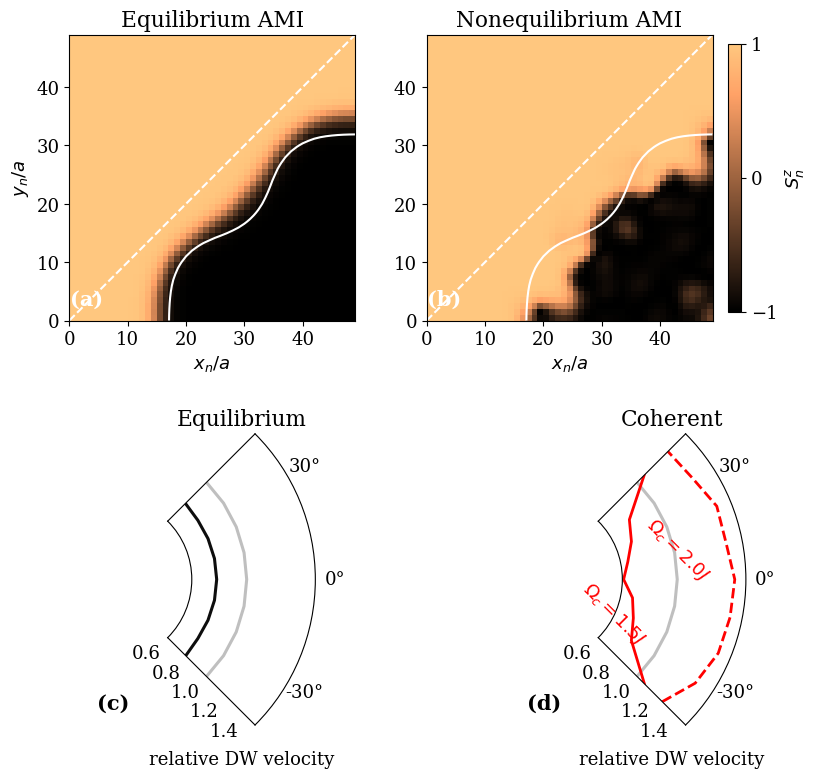

In [8]:
rows = split.(readlines(summary_path)[2:end], '	')

angles_deg = parse.(Float64, [row[3] for row in rows if row[1] == "no_ami"])
angles_rad = deg2rad.(angles_deg)

no_ami_ratio = parse.(Float64, [row[5] for row in rows if row[1] == "no_ami"])
eq_ratio = parse.(Float64, [row[5] for row in rows if row[1] == "equilibrium_mu0"])
coh1_ratio = parse.(Float64, [row[5] for row in rows if row[1] == "coherent_w1p5"])
coh2_ratio = parse.(Float64, [row[5] for row in rows if row[1] == "coherent_w2p0"])

initial_sz = Array{Float64}(readdlm(initial_map_path, Float64))
no_ami_final_sz = Array{Float64}(readdlm(no_ami_map_path, Float64))
eq_final_sz = Array{Float64}(readdlm(eq_map_path, Float64))
coh_final_sz = Array{Float64}(readdlm(coh_map_path, Float64))

plt.rc("font", family="serif", size=13)

fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.38, wspace=0.25)

ax1 = fig.add_subplot(gs[1, 1])
ax2 = fig.add_subplot(gs[1, 2], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(gs[2, 1], projection="polar")
ax4 = fig.add_subplot(gs[2, 2], projection="polar")

mesh1 = ax1.pcolormesh(eq_final_sz', cmap="copper", vmin=-1.0, vmax=1.0)
ax1.contour(initial_sz', [0.0], colors="white", linestyles="--")
ax1.contour(no_ami_final_sz', [0.0], colors="white")

mesh2 = ax2.pcolormesh(coh_final_sz', cmap="copper", vmin=-1.0, vmax=1.0)
ax2.contour(initial_sz', [0.0], colors="white", linestyles="--")
ax2.contour(no_ami_final_sz', [0.0], colors="white")

ax1.set_title("Equilibrium AMI")
ax2.set_title("Nonequilibrium AMI")
ax1.set_xlabel(raw"$x_n/a$")
ax2.set_xlabel(raw"$x_n/a$")
ax1.set_ylabel(raw"$y_n/a$")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax1.set_xlim(0, Nx - 1)
ax1.set_ylim(0, Ny - 1)

cbar = fig.colorbar(mesh2, ax=[ax1, ax2], shrink=0.92, pad=0.02)
cbar.set_label(raw"$S_n^z$")
cbar.set_ticks([-1.0, 0.0, 1.0])

ax3.plot(angles_rad, no_ami_ratio, color="0.75", linewidth=2.2)
ax3.plot(angles_rad, eq_ratio, color="0.05", linewidth=2.2)

ax4.plot(angles_rad, no_ami_ratio, color="0.75", linewidth=2.2)
ax4.plot(angles_rad, coh1_ratio, color="red", linewidth=2.0)
ax4.plot(angles_rad, coh2_ratio, color="red", linewidth=2.0, linestyle="--")

for ax in (ax3, ax4)
    ax.set_thetamin(-45)
    ax.set_thetamax(45)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.grid(false)
    ax.set_rorigin(0)
    ax.set_rmin(0.6)
    ax.set_rmax(1.5)
    ax.set_xlabel("relative DW velocity", labelpad=18)
end

ax3.set_title("Equilibrium")
ax4.set_title("Coherent")
ax4.text(0.30, 0.28, raw"$\Omega_c = 1.5 J$", transform=ax4.transAxes, color="red", rotation=-45, ha="center")
ax4.text(0.52, 0.50, raw"$\Omega_c = 2.0 J$", transform=ax4.transAxes, color="red", rotation=-45, ha="center")

for (label, ax, color) in zip(["(a)", "(b)", "(c)", "(d)"], [ax1, ax2, ax3, ax4], ["white", "white", "black", "black"])
    ax.text(0.06, 0.04, label, transform=ax.transAxes, ha="center", va="bottom", fontsize=15, color=color, fontweight="bold")
end


## 5. Cached Outputs

After the run cell finishes, the figure can be rebuilt from just five small files in `examples/data/domain_wall_ami_fig4`:

- `velocity_summary.tsv`,
- `representative_initial_sz.txt`,
- `representative_no_ami_final_sz.txt`,
- `representative_equilibrium_mu0_final_sz.txt`, and
- `representative_coherent_w2p0_final_sz.txt`.

That is the minimal dataset used by the plotting cell above.
